STEP 0 : THE BUY LAPTOP DATASET
      Age  Income Student     Credit Interest BuyLaptop
0   Young    High     Yes       Good     High       Yes
1  Middle  Medium     Yes  Excellent     High       Yes
2  Senior     Low     Yes       Good     High       Yes
3   Young  Medium      No       Good     High        No
4  Middle    High      No  Excellent     High        No
5  Senior  Medium     Yes       Poor      Low        No
6   Young     Low      No       Good      Low        No
7  Middle    High     Yes       Poor   Medium        No
8  Senior    High     Yes  Excellent     High       Yes
9   Young  Medium      No       Poor   Medium        No

Total examples: 10   |   Positive (Yes): 4   |   Negative (No): 6

STEP 1 : RUNNING SEQUENTIAL COVERING
--- Round 1 ---
Remaining positives before this round : 4
Learned rule                         : IF Student=Yes AND Interest=High THEN BuyLaptop = Yes
Covers                               : 4 positive(s), 0 negative(s)
Precision                   

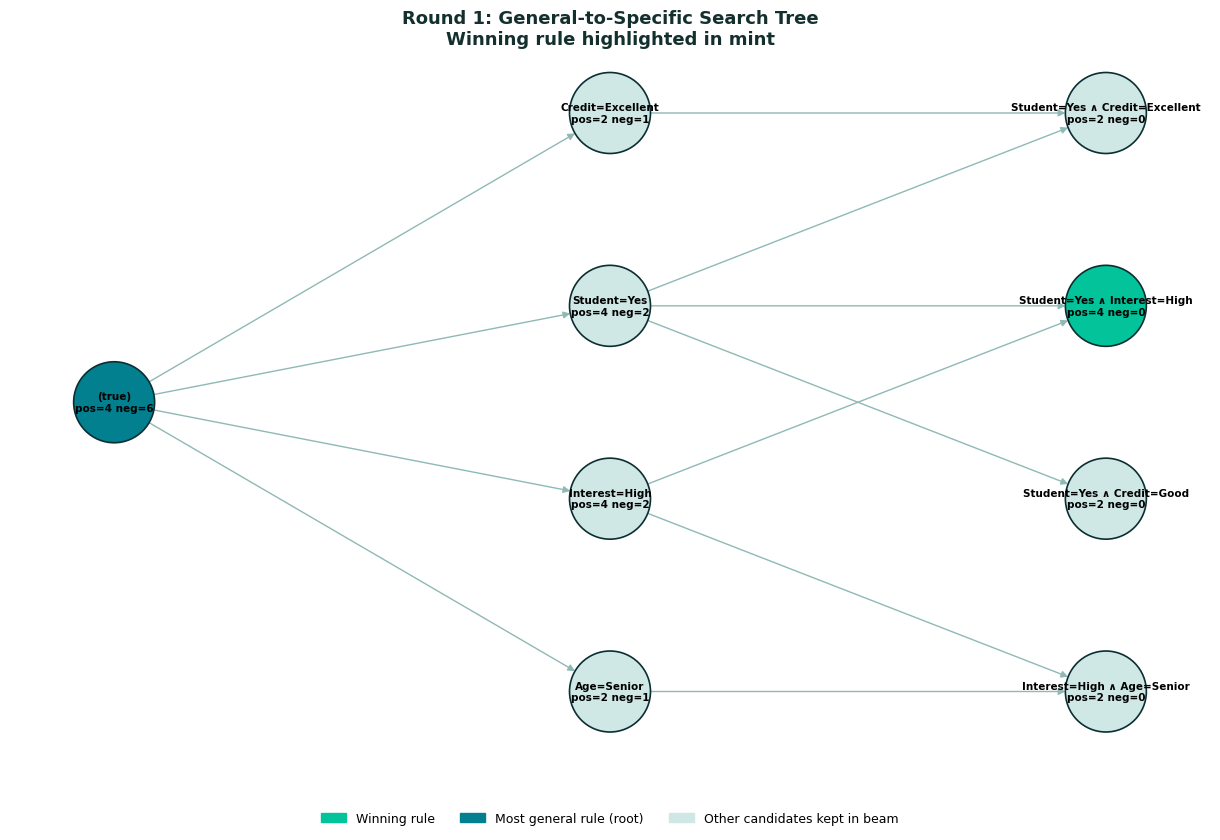

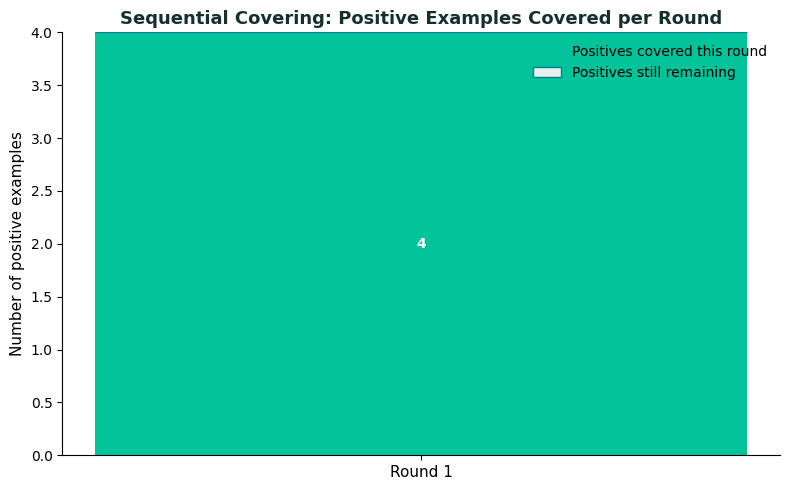

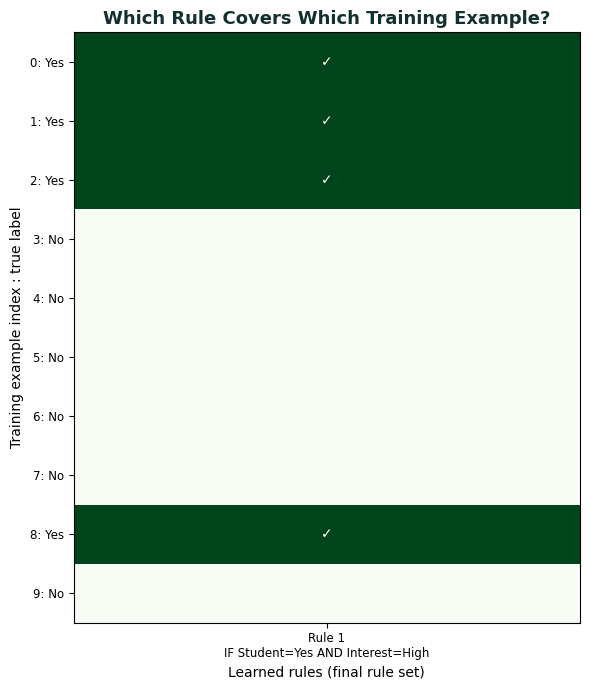

In [4]:
"""
Sequential Covering Algorithm — Full Implementation with Visual Graphs
========================================================================
Module 2: Learning Sets of Rules | BCI702

Dataset: BuyLaptop

This program will:
  1. Print the BuyLaptop dataset (10 examples)
  2. Run LEARN-ONE-RULE using general-to-specific BEAM SEARCH
  3. Run SEQUENTIAL-COVERING
  4. Remove covered positive examples after each learned rule
  5. Display:
       - Search tree for each round
       - Bar chart of positive coverage per round
       - Heatmap showing which final rule covers each example
"""

!pip install networkx -q

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

# ------------------------------------------------------------------
# 1. THE DATASET — BUY LAPTOP
# ------------------------------------------------------------------

columns = [
    "Age",
    "Income",
    "Student",
    "Credit",
    "Interest",
    "BuyLaptop"
]

data = [

    {
        "Age": "Young",
        "Income": "High",
        "Student": "Yes",
        "Credit": "Good",
        "Interest": "High",
        "BuyLaptop": "Yes"
    },

    {
        "Age": "Middle",
        "Income": "Medium",
        "Student": "Yes",
        "Credit": "Excellent",
        "Interest": "High",
        "BuyLaptop": "Yes"
    },

    {
        "Age": "Senior",
        "Income": "Low",
        "Student": "Yes",
        "Credit": "Good",
        "Interest": "High",
        "BuyLaptop": "Yes"
    },

    {
        "Age": "Young",
        "Income": "Medium",
        "Student": "No",
        "Credit": "Good",
        "Interest": "High",
        "BuyLaptop": "No"
    },

    {
        "Age": "Middle",
        "Income": "High",
        "Student": "No",
        "Credit": "Excellent",
        "Interest": "High",
        "BuyLaptop": "No"
    },

    {
        "Age": "Senior",
        "Income": "Medium",
        "Student": "Yes",
        "Credit": "Poor",
        "Interest": "Low",
        "BuyLaptop": "No"
    },

    {
        "Age": "Young",
        "Income": "Low",
        "Student": "No",
        "Credit": "Good",
        "Interest": "Low",
        "BuyLaptop": "No"
    },

    {
        "Age": "Middle",
        "Income": "High",
        "Student": "Yes",
        "Credit": "Poor",
        "Interest": "Medium",
        "BuyLaptop": "No"
    },

    {
        "Age": "Senior",
        "Income": "High",
        "Student": "Yes",
        "Credit": "Excellent",
        "Interest": "High",
        "BuyLaptop": "Yes"
    },

    {
        "Age": "Young",
        "Income": "Medium",
        "Student": "No",
        "Credit": "Poor",
        "Interest": "Medium",
        "BuyLaptop": "No"
    }
]

df = pd.DataFrame(data, columns=columns)

TARGET_ATTR = "BuyLaptop"
TARGET_VAL = "Yes"

ATTRIBUTES = [
    c for c in columns
    if c != TARGET_ATTR
]

# Domain (possible values) of every attribute
DOMAIN = {
    attr: sorted(df[attr].unique())
    for attr in ATTRIBUTES
}


# ------------------------------------------------------------------
# 2. PRINT DATASET
# ------------------------------------------------------------------

def print_dataset():

    print("=" * 78)
    print("STEP 0 : THE BUY LAPTOP DATASET")
    print("=" * 78)

    print(df.to_string(index=True))

    n_pos = (
        df[TARGET_ATTR] == TARGET_VAL
    ).sum()

    n_neg = (
        df[TARGET_ATTR] != TARGET_VAL
    ).sum()

    print(
        f"\nTotal examples: {len(df)}"
        f"   |   Positive (Yes): {n_pos}"
        f"   |   Negative (No): {n_neg}"
    )

    print()


# ------------------------------------------------------------------
# 3. RULE REPRESENTATION & SCORING
# ------------------------------------------------------------------

# A rule/hypothesis is represented as:
#
# {
#     "Student": "Yes",
#     "Interest": "High"
# }
#
# Empty dictionary {} means:
#
# IF (true)
#
# i.e. the rule matches every example.

def covers(rule, row):

    """
    Check whether an example satisfies
    every condition in the rule.
    """

    return all(
        row[attr] == val
        for attr, val in rule.items()
    )


def evaluate(rule, examples):

    """
    Return:

        positives_covered
        negatives_covered
        precision
    """

    covered = examples[
        examples.apply(
            lambda r: covers(rule, r),
            axis=1
        )
    ]

    pos = (
        covered[TARGET_ATTR] == TARGET_VAL
    ).sum()

    neg = (
        covered[TARGET_ATTR] != TARGET_VAL
    ).sum()

    precision = (
        pos / (pos + neg)
        if (pos + neg) > 0
        else 0.0
    )

    return pos, neg, precision


def rule_to_str(rule):

    if not rule:
        return "IF (true)"

    conds = " AND ".join(
        f"{a}={v}"
        for a, v in rule.items()
    )

    return f"IF {conds}"


# ------------------------------------------------------------------
# 4. LEARN-ONE-RULE
#    GENERAL-TO-SPECIFIC BEAM SEARCH
# ------------------------------------------------------------------

def learn_one_rule(
    examples,
    beam_width=4,
    max_conditions=None
):

    """
    Performs a general-to-specific beam search.

    Starts with the most general rule:

        IF (true)

    and gradually adds:

        attribute = value

    conditions.

    Returns:

        best_rule
        best_pos
        best_neg
        best_prec
        search_history
    """

    if max_conditions is None:
        max_conditions = len(ATTRIBUTES)

    search_history = []

    # --------------------------------------------------------------
    # DEPTH 0
    # --------------------------------------------------------------

    beam = [{}]

    depth0_pos, depth0_neg, depth0_prec = evaluate(
        {},
        examples
    )

    search_history.append({

        "depth": 0,

        "candidates": [
            (
                {},
                depth0_pos,
                depth0_neg,
                depth0_prec,
                None
            )
        ],

        "beam": [{}]

    })

    best_rule = {}

    best_pos = depth0_pos
    best_neg = depth0_neg
    best_prec = depth0_prec


    # --------------------------------------------------------------
    # GENERATE SPECIALIZATIONS
    # --------------------------------------------------------------

    for depth in range(
        1,
        max_conditions + 1
    ):

        candidates = []

        # Expand every rule currently in the beam
        for parent in beam:

            used_attrs = set(
                parent.keys()
            )

            for attr in ATTRIBUTES:

                # Do not use the same attribute twice
                if attr in used_attrs:
                    continue

                for val in DOMAIN[attr]:

                    child = dict(parent)

                    child[attr] = val

                    pos, neg, prec = evaluate(
                        child,
                        examples
                    )

                    # Ignore rules that cover
                    # no positive examples
                    if pos == 0:
                        continue

                    candidates.append(
                        (
                            child,
                            pos,
                            neg,
                            prec,
                            parent
                        )
                    )


        if not candidates:
            break


        # ----------------------------------------------------------
        # RANK CANDIDATES
        # ----------------------------------------------------------
        #
        # Priority:
        #
        # 1. Pure rule (0 negatives)
        # 2. Higher precision
        # 3. Higher positive coverage
        #

        candidates.sort(
            key=lambda c: (
                c[2] == 0,
                c[3],
                c[1]
            ),
            reverse=True
        )


        # ----------------------------------------------------------
        # KEEP TOP BEAM WIDTH RULES
        # ----------------------------------------------------------

        new_beam = []

        seen = set()

        for (
            child,
            pos,
            neg,
            prec,
            parent
        ) in candidates:

            key = frozenset(
                child.items()
            )

            if key not in seen:

                seen.add(key)

                new_beam.append(child)

            if len(new_beam) >= beam_width:
                break

        beam = new_beam


        search_history.append({

            "depth": depth,

            "candidates": candidates,

            "beam": beam

        })


        # ----------------------------------------------------------
        # CHECK FOR PURE RULE
        # ----------------------------------------------------------

        pure_candidates = [
            c
            for c in candidates
            if c[2] == 0
        ]


        if pure_candidates:

            top = pure_candidates[0]

            best_rule = top[0]
            best_pos = top[1]
            best_neg = top[2]
            best_prec = top[3]

            break


        else:

            top = candidates[0]

            if (
                (top[2] == 0,
                 top[3],
                 top[1])
                >
                (best_neg == 0,
                 best_prec,
                 best_pos)
            ):

                best_rule = top[0]
                best_pos = top[1]
                best_neg = top[2]
                best_prec = top[3]


    return (
        best_rule,
        best_pos,
        best_neg,
        best_prec,
        search_history
    )


# ------------------------------------------------------------------
# 5. SEQUENTIAL COVERING
# ------------------------------------------------------------------

def sequential_covering(
    beam_width=4
):

    """
    Learn rules repeatedly.

    After each rule is learned,
    remove the positive examples
    covered by that rule.

    Continue until all positive
    examples are covered.
    """

    working = df.copy()

    rules = []

    round_logs = []

    round_num = 1


    while (
        working[TARGET_ATTR] == TARGET_VAL
    ).sum() > 0:


        # ----------------------------------------------------------
        # LEARN ONE RULE
        # ----------------------------------------------------------

        (
            rule,
            pos,
            neg,
            prec,
            history
        ) = learn_one_rule(
            working,
            beam_width=beam_width
        )


        # ----------------------------------------------------------
        # FIND COVERED EXAMPLES
        # ----------------------------------------------------------

        covered_mask = working.apply(
            lambda r: covers(rule, r),
            axis=1
        )

        covered_examples = working[
            covered_mask
        ]


        covered_positive_idx = (
            covered_examples[
                covered_examples[TARGET_ATTR] == TARGET_VAL
            ]
            .index
            .tolist()
        )


        # ----------------------------------------------------------
        # PRINT ROUND INFORMATION
        # ----------------------------------------------------------

        remaining_before = (
            working[TARGET_ATTR] == TARGET_VAL
        ).sum()


        print(
            f"--- Round {round_num} ---"
        )

        print(
            "Remaining positives before this round : "
            f"{remaining_before}"
        )

        print(
            "Learned rule                         : "
            f"{rule_to_str(rule)} "
            f"THEN {TARGET_ATTR} = {TARGET_VAL}"
        )

        print(
            "Covers                               : "
            f"{pos} positive(s), {neg} negative(s)"
        )

        print(
            "Precision                            : "
            f"{prec:.2f}"
        )

        print(
            "Positive example indices covered     : "
            f"{covered_positive_idx}"
        )

        print()


        # ----------------------------------------------------------
        # STORE RULE
        # ----------------------------------------------------------

        rules.append(rule)

        round_logs.append({

            "round": round_num,

            "rule": rule,

            "pos_covered": pos,

            "neg_covered": neg,

            "precision": prec,

            "covered_positive_idx":
                covered_positive_idx,

            "history": history,

            "remaining_pos_before":
                remaining_before

        })


        # ----------------------------------------------------------
        # REMOVE COVERED POSITIVE EXAMPLES
        # ----------------------------------------------------------

        working = working.drop(
            index=covered_positive_idx
        )

        round_num += 1


        # Safety check
        if pos == 0:

            print(
                "No further progress possible — "
                "stopping to avoid an infinite loop."
            )

            break


    return rules, round_logs


# ------------------------------------------------------------------
# 6. GRAPH — SEARCH TREE PER ROUND
# ------------------------------------------------------------------

def plot_search_tree(
    history,
    winning_rule,
    round_num
):

    G = nx.DiGraph()

    labels = {}

    node_colors = []

    node_id_of_rule = {}


    # --------------------------------------------------------------
    # CREATE UNIQUE NODE ID
    # --------------------------------------------------------------

    def node_id(rule):

        key = frozenset(
            rule.items()
        )

        if key not in node_id_of_rule:

            node_id_of_rule[key] = (
                f"n{len(node_id_of_rule)}"
            )

        return node_id_of_rule[key]


    # --------------------------------------------------------------
    # ROOT NODE
    # --------------------------------------------------------------

    (
        root_pos,
        root_neg,
        root_prec
    ) = history[0]["candidates"][0][1:4]


    root_id = node_id({})

    G.add_node(root_id)

    labels[root_id] = (
        f"(true)\n"
        f"pos={root_pos} "
        f"neg={root_neg}"
    )


    winning_key = frozenset(
        winning_rule.items()
    )


    # --------------------------------------------------------------
    # DETERMINE RULES KEPT IN BEAM
    # --------------------------------------------------------------

    kept_keys = set()

    for level in history:

        for r in level["beam"]:

            kept_keys.add(
                frozenset(r.items())
            )


    kept_keys.add(winning_key)


    # --------------------------------------------------------------
    # BUILD GRAPH
    # --------------------------------------------------------------

    for level in history[1:]:

        for (
            child,
            pos,
            neg,
            prec,
            parent
        ) in level["candidates"]:

            key = frozenset(
                child.items()
            )

            # Only display rules that survived
            # beam selection or the winning rule
            if key not in kept_keys:
                continue


            cid = node_id(child)

            pid = node_id(parent)


            if not G.has_node(cid):

                G.add_node(cid)

                label = " ∧ ".join(
                    f"{a}={v}"
                    for a, v in child.items()
                )

                labels[cid] = (
                    f"{label}\n"
                    f"pos={pos} "
                    f"neg={neg}"
                )


            G.add_edge(
                pid,
                cid
            )


    # --------------------------------------------------------------
    # CREATE LAYERS
    # --------------------------------------------------------------

    for layer, nodes in enumerate(
        nx.bfs_layers(
            G,
            root_id
        )
    ):

        for n in nodes:

            G.nodes[n]["layer"] = layer


    pos_layout = nx.multipartite_layout(
        G,
        subset_key="layer"
    )


    # --------------------------------------------------------------
    # NODE COLORS
    # --------------------------------------------------------------

    for n in G.nodes():

        key = None

        for k, v in node_id_of_rule.items():

            if v == n:

                key = k

                break


        if key == winning_key:

            # Winner
            node_colors.append(
                "#02C39A"
            )

        elif n == root_id:

            # Root
            node_colors.append(
                "#028090"
            )

        else:

            # Other beam candidates
            node_colors.append(
                "#CFE8E5"
            )


    # --------------------------------------------------------------
    # DRAW GRAPH
    # --------------------------------------------------------------

    plt.figure(
        figsize=(12, 7)
    )


    nx.draw(
        G,
        pos_layout,
        labels=labels,
        with_labels=True,
        node_color=node_colors,
        node_size=3400,
        font_size=7.5,
        font_weight="bold",
        arrows=True,
        edge_color="#8FB9B5",
        linewidths=1.2,
        edgecolors="#0B2E33"
    )


    plt.title(
        f"Round {round_num}: "
        f"General-to-Specific Search Tree\n"
        f"Winning rule highlighted in mint",
        fontsize=13,
        fontweight="bold",
        color="#13302E"
    )


    winner_patch = mpatches.Patch(
        color="#02C39A",
        label="Winning rule"
    )

    root_patch = mpatches.Patch(
        color="#028090",
        label="Most general rule (root)"
    )

    other_patch = mpatches.Patch(
        color="#CFE8E5",
        label="Other candidates kept in beam"
    )


    plt.legend(
        handles=[
            winner_patch,
            root_patch,
            other_patch
        ],
        loc="lower center",
        bbox_to_anchor=(0.5, -0.12),
        ncol=3,
        frameon=False,
        fontsize=9
    )


    plt.show()


# ------------------------------------------------------------------
# 7. GRAPH — COVERAGE BAR CHART
# ------------------------------------------------------------------

def plot_coverage_bar(
    round_logs
):

    rounds = [
        f"Round {rl['round']}"
        for rl in round_logs
    ]

    covered = [
        rl["pos_covered"]
        for rl in round_logs
    ]


    remaining_after = []

    total_pos = (
        df[TARGET_ATTR] == TARGET_VAL
    ).sum()

    running = total_pos


    for rl in round_logs:

        running -= rl["pos_covered"]

        remaining_after.append(
            running
        )


    x = range(
        len(rounds)
    )


    fig, ax = plt.subplots(
        figsize=(8, 5)
    )


    # Positives covered
    ax.bar(
        x,
        covered,
        color="#02C39A",
        label="Positives covered this round"
    )


    # Positives remaining
    ax.bar(
        x,
        remaining_after,
        bottom=covered,
        color="#E8F0EF",
        edgecolor="#028090",
        label="Positives still remaining"
    )


    # Add numbers to bars
    for i, (
        c,
        r
    ) in enumerate(
        zip(
            covered,
            remaining_after
        )
    ):

        if c > 0:

            ax.text(
                i,
                c / 2,
                str(c),
                ha="center",
                va="center",
                fontweight="bold",
                color="white"
            )


        if r > 0:

            ax.text(
                i,
                c + r / 2,
                str(r),
                ha="center",
                va="center",
                fontweight="bold",
                color="#13302E"
            )


    ax.set_xticks(
        list(x)
    )

    ax.set_xticklabels(
        rounds,
        fontsize=11
    )

    ax.set_ylabel(
        "Number of positive examples",
        fontsize=11
    )


    ax.set_title(
        "Sequential Covering: "
        "Positive Examples Covered per Round",
        fontsize=13,
        fontweight="bold",
        color="#13302E"
    )


    ax.legend(
        loc="upper right",
        frameon=False
    )


    ax.spines[
        ["top", "right"]
    ].set_visible(False)


    plt.tight_layout()

    plt.show()


# ------------------------------------------------------------------
# 8. GRAPH — FINAL COVERAGE HEATMAP
# ------------------------------------------------------------------

def plot_coverage_heatmap(
    rules
):

    n = len(df)

    m = len(rules)


    matrix = [

        [
            1
            if covers(
                rule,
                df.loc[i]
            )
            else 0

            for rule in rules
        ]

        for i in range(n)

    ]


    fig, ax = plt.subplots(
        figsize=(5 + m, 7)
    )


    ax.imshow(
        matrix,
        cmap="Greens",
        aspect="auto",
        vmin=0,
        vmax=1
    )


    # --------------------------------------------------------------
    # X AXIS
    # --------------------------------------------------------------

    ax.set_xticks(
        range(m)
    )

    ax.set_xticklabels(
        [
            f"Rule {i+1}\n"
            f"{rule_to_str(r)}"

            for i, r
            in enumerate(rules)
        ],
        fontsize=8.5
    )


    # --------------------------------------------------------------
    # Y AXIS
    # --------------------------------------------------------------

    ax.set_yticks(
        range(n)
    )


    row_labels = [

        f"{i}: "
        f"{df.loc[i, 'BuyLaptop']}"

        for i in range(n)

    ]


    ax.set_yticklabels(
        row_labels,
        fontsize=8.5
    )


    # --------------------------------------------------------------
    # ADD CHECK MARKS
    # --------------------------------------------------------------

    for i in range(n):

        for j in range(m):

            if matrix[i][j]:

                ax.text(
                    j,
                    i,
                    "✓",
                    ha="center",
                    va="center",
                    color="white",
                    fontweight="bold"
                )


    ax.set_title(
        "Which Rule Covers Which Training Example?",
        fontsize=13,
        fontweight="bold",
        color="#13302E"
    )


    ax.set_xlabel(
        "Learned rules (final rule set)"
    )

    ax.set_ylabel(
        "Training example index : true label"
    )


    plt.tight_layout()

    plt.show()


# ------------------------------------------------------------------
# 9. MAIN PROGRAM
# ------------------------------------------------------------------

print_dataset()


print("=" * 78)
print("STEP 1 : RUNNING SEQUENTIAL COVERING")
print("=" * 78)


rules, round_logs = sequential_covering(
    beam_width=4
)


# ------------------------------------------------------------------
# FINAL RULE SET
# ------------------------------------------------------------------

print("=" * 78)
print("FINAL LEARNED RULE SET")
print("=" * 78)


for i, r in enumerate(
    rules,
    start=1
):

    print(
        f"Rule {i}: "
        f"{rule_to_str(r)} "
        f"THEN "
        f"{TARGET_ATTR} = {TARGET_VAL}"
    )


print()


# ------------------------------------------------------------------
# GENERATE GRAPHS
# ------------------------------------------------------------------

print("=" * 78)
print("STEP 2 : GENERATING GRAPHS")
print("=" * 78)


# Search tree for every round
for rl in round_logs:

    plot_search_tree(
        rl["history"],
        rl["rule"],
        rl["round"]
    )


# Positive coverage
plot_coverage_bar(
    round_logs
)


# Final rule/example coverage
plot_coverage_heatmap(
    rules
)



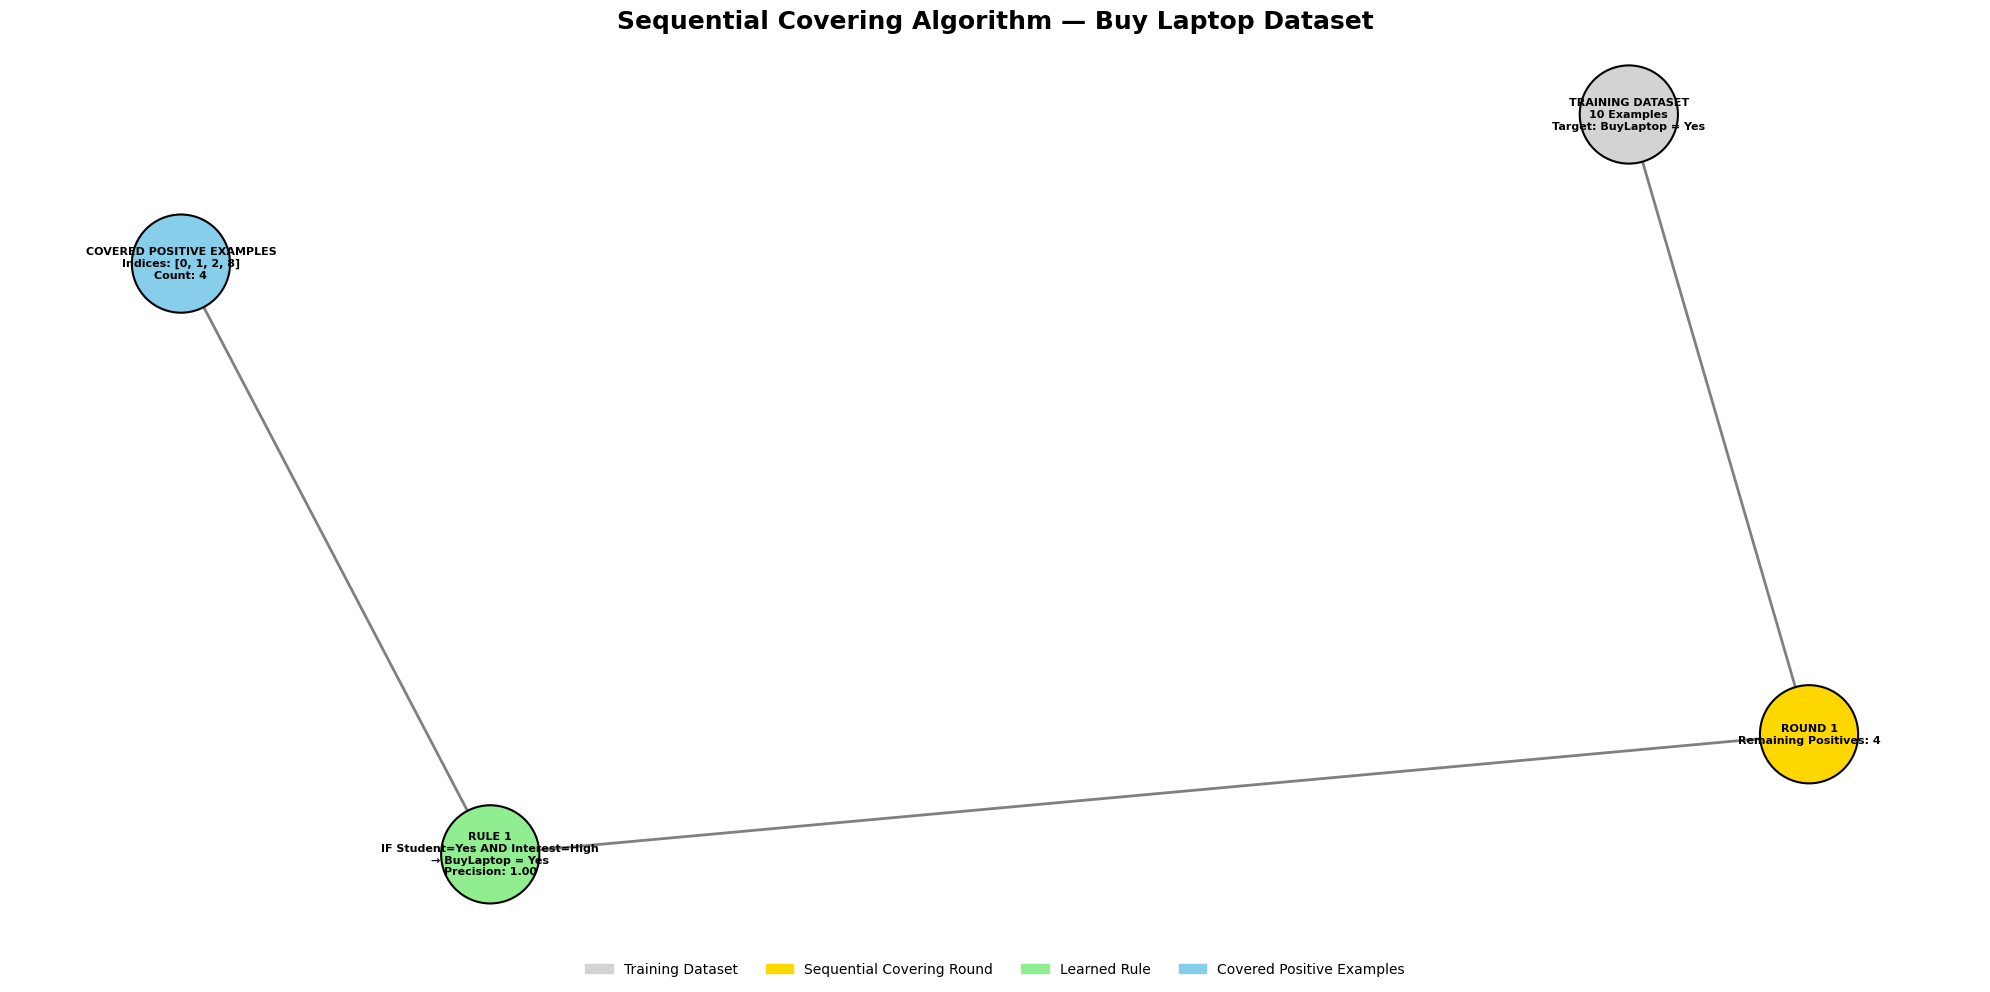

In [7]:
# ================================================================
# VISUALIZE SEQUENTIAL COVERING — BUY LAPTOP DATASET
# ================================================================

def visualize_sequential_covering(round_logs):

    G = nx.DiGraph()

    # ------------------------------------------------------------
    # ROOT NODE
    # ------------------------------------------------------------

    G.add_node(
        "Training Dataset",
        node_type="dataset",
        label=(
            "TRAINING DATASET\n"
            f"{len(df)} Examples\n"
            f"Target: {TARGET_ATTR} = {TARGET_VAL}"
        )
    )

    previous = "Training Dataset"


    # ------------------------------------------------------------
    # CREATE NODES FOR EACH SEQUENTIAL COVERING ROUND
    # ------------------------------------------------------------

    for item in round_logs:

        rule_no = item["round"]
        rule = item["rule"]

        covered_positive = item[
            "covered_positive_idx"
        ]

        # --------------------------------------------------------
        # SEED / ROUND NODE
        # --------------------------------------------------------

        seed_node = f"SC Seed {rule_no}"

        G.add_node(
            seed_node,
            node_type="seed",
            label=(
                f"ROUND {rule_no}\n"
                f"Remaining Positives: "
                f"{item['remaining_pos_before']}"
            )
        )

        G.add_edge(
            previous,
            seed_node
        )


        # --------------------------------------------------------
        # RULE NODE
        # --------------------------------------------------------

        rule_node = f"SC Rule {rule_no}"

        G.add_node(
            rule_node,
            node_type="rule",
            label=(
                f"RULE {rule_no}\n"
                f"{rule_to_str(rule)}\n"
                f"→ {TARGET_ATTR} = {TARGET_VAL}\n"
                f"Precision: "
                f"{item['precision']:.2f}"
            )
        )

        G.add_edge(
            seed_node,
            rule_node
        )


        # --------------------------------------------------------
        # COVERED EXAMPLES NODE
        # --------------------------------------------------------

        covered_node = f"Covered {rule_no}"

        G.add_node(
            covered_node,
            node_type="covered",
            label=(
                f"COVERED POSITIVE EXAMPLES\n"
                f"Indices: {covered_positive}\n"
                f"Count: {item['pos_covered']}"
            )
        )

        G.add_edge(
            rule_node,
            covered_node
        )


        # The next round starts from the examples
        # remaining after this rule
        previous = covered_node


    # ============================================================
    # COLORS
    # ============================================================

    colors = []

    for node in G.nodes:

        node_type = G.nodes[node].get(
            "node_type"
        )

        if node_type == "dataset":

            colors.append(
                "lightgray"
            )

        elif node_type == "seed":

            colors.append(
                "gold"
            )

        elif node_type == "rule":

            colors.append(
                "lightgreen"
            )

        elif node_type == "covered":

            colors.append(
                "skyblue"
            )

        else:

            colors.append(
                "white"
            )


    # ============================================================
    # LABELS
    # ============================================================

    labels = {}

    for node in G.nodes:

        labels[node] = G.nodes[node].get(
            "label",
            node
        )


    # ============================================================
    # DRAW GRAPH
    # ============================================================

    plt.figure(
        figsize=(20, 10)
    )

    position = nx.spring_layout(
        G,
        seed=42,
        k=2.5
    )


    # ------------------------------------------------------------
    # EDGES
    # ------------------------------------------------------------

    nx.draw_networkx_edges(
        G,
        position,
        arrows=True,
        arrowsize=20,
        edge_color="gray",
        width=2
    )


    # ------------------------------------------------------------
    # NODES
    # ------------------------------------------------------------

    nx.draw_networkx_nodes(
        G,
        position,
        node_color=colors,
        node_size=5000,
        edgecolors="black",
        linewidths=1.5
    )


    # ------------------------------------------------------------
    # LABELS
    # ------------------------------------------------------------

    nx.draw_networkx_labels(
        G,
        position,
        labels,
        font_size=8,
        font_weight="bold"
    )


    # ============================================================
    # TITLE
    # ============================================================

    plt.title(
        "Sequential Covering Algorithm — Buy Laptop Dataset",
        fontsize=18,
        fontweight="bold"
    )


    # ============================================================
    # LEGEND
    # ============================================================

    dataset_patch = mpatches.Patch(
        color="lightgray",
        label="Training Dataset"
    )

    seed_patch = mpatches.Patch(
        color="gold",
        label="Sequential Covering Round"
    )

    rule_patch = mpatches.Patch(
        color="lightgreen",
        label="Learned Rule"
    )

    covered_patch = mpatches.Patch(
        color="skyblue",
        label="Covered Positive Examples"
    )


    plt.legend(
        handles=[
            dataset_patch,
            seed_patch,
            rule_patch,
            covered_patch
        ],
        loc="upper center",
        bbox_to_anchor=(0.5, -0.02),
        ncol=4,
        frameon=False,
        fontsize=10
    )


    plt.axis("off")

    plt.tight_layout()

    plt.show()


# ================================================================
# RUN VISUALIZATION
# ================================================================

visualize_sequential_covering(
    round_logs
)



In [9]:
# ============================================================
# AQ ALGORITHM — BUY LAPTOP DATASET
# ============================================================

def aq_rule_quality(
    rule,
    data,
    target,
    positive_class
):

    """
    Calculate the quality/purity of a rule.

    Quality = Positive examples covered /
              Total examples covered
    """

    # --------------------------------------------------------
    # Find examples covered by the rule
    # --------------------------------------------------------

    covered = data[
        data.apply(
            lambda row: covers(rule, row),
            axis=1
        )
    ]

    # If no example is covered
    if covered.empty:
        return 0.0


    # --------------------------------------------------------
    # Count positive and negative examples
    # --------------------------------------------------------

    positives = (
        covered[target] == positive_class
    ).sum()

    negatives = (
        covered[target] != positive_class
    ).sum()


    # --------------------------------------------------------
    # Calculate purity
    # --------------------------------------------------------

    total = positives + negatives

    if total == 0:
        return 0.0

    return positives / total


# ============================================================
# GENERATE STAR
# ============================================================

def generate_star(
    seed,
    data,
    target,
    positive_class
):

    """
    Generate the STAR for the selected positive seed.

    Each candidate rule uses one attribute-value
    condition taken from the seed.
    """

    star = []


    # --------------------------------------------------------
    # Get all predictor attributes
    # --------------------------------------------------------

    attributes = [
        column
        for column in data.columns
        if column != target
    ]


    # --------------------------------------------------------
    # Generate one-condition rules
    # --------------------------------------------------------

    for attribute in attributes:

        # Candidate condition based on seed
        candidate = {
            attribute: seed[attribute]
        }


        # Calculate rule quality
        quality = aq_rule_quality(
            candidate,
            data,
            target,
            positive_class
        )


        # Count covered examples
        covered = data[
            data.apply(
                lambda row: covers(
                    candidate,
                    row
                ),
                axis=1
            )
        ]


        positives = (
            covered[target] == positive_class
        ).sum()


        negatives = (
            covered[target] != positive_class
        ).sum()


        # Store candidate
        star.append({

            "rule": candidate,

            "quality": quality,

            "positive_covered": positives,

            "negative_covered": negatives

        })


    # --------------------------------------------------------
    # Sort STAR
    # --------------------------------------------------------
    #
    # Highest quality first.
    # If quality is equal, prefer the rule
    # covering more positive examples.
    #

    star.sort(
        key=lambda x: (
            x["quality"],
            x["positive_covered"]
        ),
        reverse=True
    )


    return star


# ============================================================
# AQ ALGORITHM
# ============================================================

def AQ_algorithm(
    data,
    target="BuyLaptop",
    positive_class="Yes"
):

    """
    AQ algorithm for the BuyLaptop dataset.

    Steps:
        1. Select a positive example as seed
        2. Generate STAR
        3. Evaluate candidate rules
        4. Select the highest-quality rule
    """


    # --------------------------------------------------------
    # SELECT POSITIVE EXAMPLES
    # --------------------------------------------------------

    positive_examples = data[
        data[target] == positive_class
    ]


    if positive_examples.empty:

        print(
            "No positive examples found."
        )

        return None


    # --------------------------------------------------------
    # SELECT FIRST POSITIVE EXAMPLE AS SEED
    # --------------------------------------------------------

    seed_index = positive_examples.index[0]

    seed = positive_examples.loc[
        seed_index
    ]


    # --------------------------------------------------------
    # PRINT HEADER
    # --------------------------------------------------------

    print("\n")

    print(
        "=" * 75
    )

    print(
        "AQ ALGORITHM — BUY LAPTOP DATASET"
    )

    print(
        "=" * 75
    )


    # --------------------------------------------------------
    # PRINT DATASET INFORMATION
    # --------------------------------------------------------

    print("\nTARGET ATTRIBUTE:")
    print(
        f"{target} = {positive_class}"
    )


    print("\nSELECTED SEED:")

    print(
        f"Example Index: {seed_index}"
    )

    print(
        seed.to_dict()
    )


    # --------------------------------------------------------
    # GENERATE STAR
    # --------------------------------------------------------

    star = generate_star(
        seed,
        data,
        target,
        positive_class
    )


    print("\n")
    print(
        "=" * 75
    )

    print(
        "GENERATED STAR"
    )

    print(
        "=" * 75
    )


    # --------------------------------------------------------
    # DISPLAY CANDIDATE RULES
    # --------------------------------------------------------

    for i, candidate in enumerate(
        star,
        1
    ):

        rule = candidate["rule"]

        quality = candidate["quality"]

        pos = candidate[
            "positive_covered"
        ]

        neg = candidate[
            "negative_covered"
        ]


        print(
            f"{i}. "
            f"{rule_to_str(rule)}"
        )

        print(
            f"   Quality            : "
            f"{quality:.2f}"
        )

        print(
            f"   Positive covered   : "
            f"{pos}"
        )

        print(
            f"   Negative covered   : "
            f"{neg}"
        )

        print()


    # --------------------------------------------------------
    # SELECT BEST RULE
    # --------------------------------------------------------

    best = star[0]

    final_rule = best["rule"]


    # --------------------------------------------------------
    # PRINT FINAL RULE
    # --------------------------------------------------------

    print(
        "=" * 75
    )

    print(
        "FINAL AQ RULE"
    )

    print(
        "=" * 75
    )


    print(
        f"IF {rule_to_str(final_rule)} "
        f"THEN {target} = {positive_class}"
    )


    print(
        f"\nRule Quality: "
        f"{best['quality']:.2f}"
    )

    print(
        f"Positive Examples Covered: "
        f"{best['positive_covered']}"
    )

    print(
        f"Negative Examples Covered: "
        f"{best['negative_covered']}"
    )


    # --------------------------------------------------------
    # RETURN RESULT
    # --------------------------------------------------------

    return {

        "seed_index": seed_index,

        "seed": seed.to_dict(),

        "star": star,

        "final_rule": final_rule,

        "quality": best["quality"],

        "positive_covered":
            best["positive_covered"],

        "negative_covered":
            best["negative_covered"]

    }


# ============================================================
# RUN AQ
# ============================================================

aq_result = AQ_algorithm(
    df,
    target="BuyLaptop",
    positive_class="Yes"
)




AQ ALGORITHM — BUY LAPTOP DATASET

TARGET ATTRIBUTE:
BuyLaptop = Yes

SELECTED SEED:
Example Index: 0
{'Age': 'Young', 'Income': 'High', 'Student': 'Yes', 'Credit': 'Good', 'Interest': 'High', 'BuyLaptop': 'Yes'}


GENERATED STAR
1. IF Student=Yes
   Quality            : 0.67
   Positive covered   : 4
   Negative covered   : 2

2. IF Interest=High
   Quality            : 0.67
   Positive covered   : 4
   Negative covered   : 2

3. IF Income=High
   Quality            : 0.50
   Positive covered   : 2
   Negative covered   : 2

4. IF Credit=Good
   Quality            : 0.50
   Positive covered   : 2
   Negative covered   : 2

5. IF Age=Young
   Quality            : 0.25
   Positive covered   : 1
   Negative covered   : 3

FINAL AQ RULE
IF IF Student=Yes THEN BuyLaptop = Yes

Rule Quality: 0.67
Positive Examples Covered: 4
Negative Examples Covered: 2


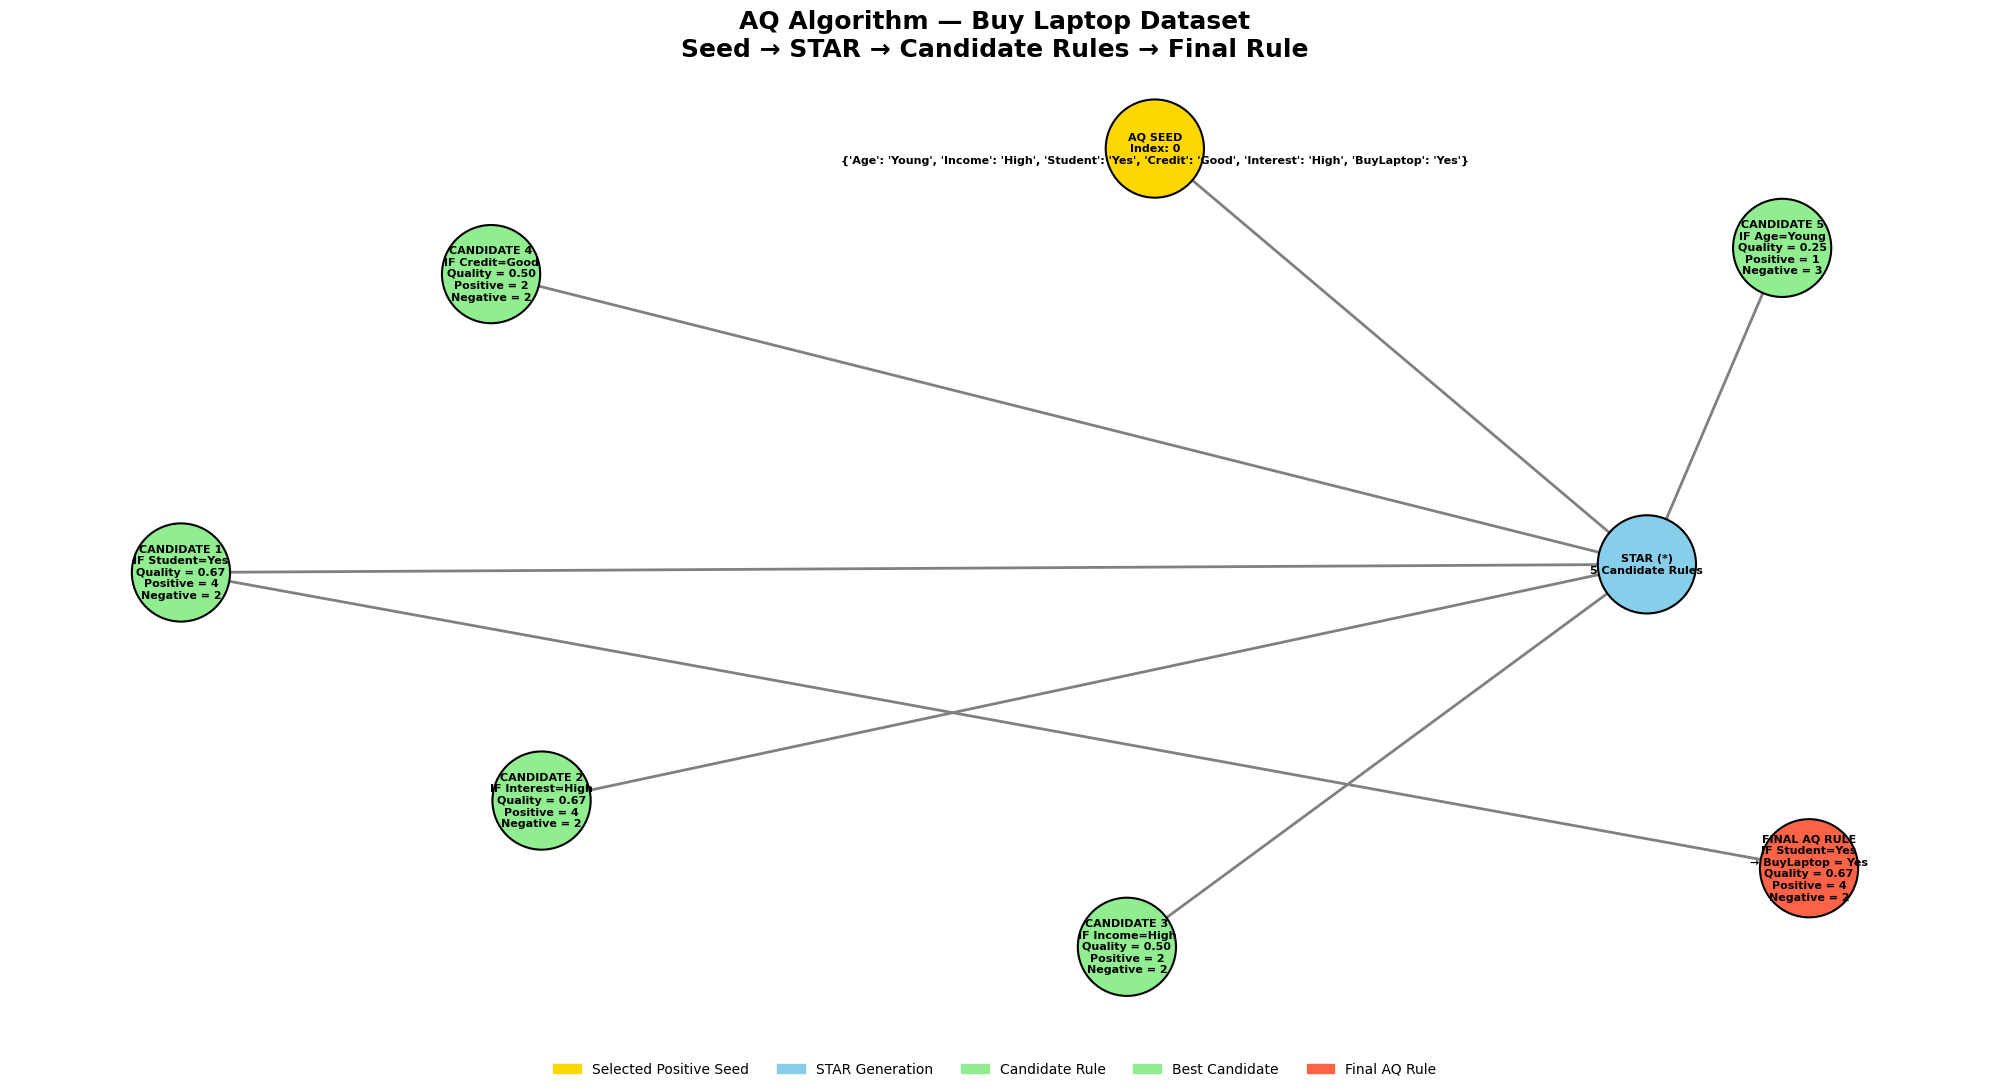

In [10]:
# ============================================================
# VISUALIZE AQ ALGORITHM — BUY LAPTOP DATASET
# ============================================================

def visualize_aq(result):

    G = nx.DiGraph()


    # ========================================================
    # SEED NODE
    # ========================================================

    seed_node = "AQ SEED"

    G.add_node(
        seed_node,
        node_type="seed",
        label=(
            "AQ SEED\n"
            f"Index: {result['seed_index']}\n"
            f"{result['seed']}"
        )
    )


    # ========================================================
    # STAR NODE
    # ========================================================

    star_node = "AQ STAR (*)"

    G.add_node(
        star_node,
        node_type="star",
        label=(
            "STAR (*)\n"
            f"{len(result['star'])} Candidate Rules"
        )
    )


    G.add_edge(
        seed_node,
        star_node
    )


    # ========================================================
    # CANDIDATE RULE NODES
    # ========================================================

    for i, candidate in enumerate(
        result["star"],
        1
    ):

        candidate_node = (
            f"Candidate {i}"
        )


        # Get candidate information
        rule = candidate["rule"]

        quality = candidate["quality"]

        positive_covered = candidate[
            "positive_covered"
        ]

        negative_covered = candidate[
            "negative_covered"
        ]


        # ----------------------------------------------------
        # Highlight the best candidate
        # ----------------------------------------------------

        if i == 1:

            node_type = "best_candidate"

        else:

            node_type = "candidate"


        G.add_node(
            candidate_node,
            node_type=node_type,
            label=(
                f"CANDIDATE {i}\n"
                f"{rule_to_str(rule)}\n"
                f"Quality = {quality:.2f}\n"
                f"Positive = {positive_covered}\n"
                f"Negative = {negative_covered}"
            )
        )


        G.add_edge(
            star_node,
            candidate_node
        )


    # ========================================================
    # FINAL RULE NODE
    # ========================================================

    final_node = "AQ FINAL RULE"


    final_quality = result[
        "quality"
    ]

    final_positive = result[
        "positive_covered"
    ]

    final_negative = result[
        "negative_covered"
    ]


    G.add_node(
        final_node,
        node_type="final",
        label=(
            "FINAL AQ RULE\n"
            f"{rule_to_str(result['final_rule'])}\n"
            f"→ BuyLaptop = Yes\n"
            f"Quality = {final_quality:.2f}\n"
            f"Positive = {final_positive}\n"
            f"Negative = {final_negative}"
        )
    )


    # ========================================================
    # CONNECT BEST CANDIDATE TO FINAL RULE
    # ========================================================

    if len(result["star"]) > 0:

        G.add_edge(
            "Candidate 1",
            final_node
        )


    # ========================================================
    # COLORS
    # ========================================================

    colors = []


    for node in G.nodes:

        node_type = G.nodes[node].get(
            "node_type"
        )


        if node_type == "seed":

            colors.append(
                "gold"
            )


        elif node_type == "star":

            colors.append(
                "skyblue"
            )


        elif node_type == "best_candidate":

            # Best candidate
            colors.append(
                "#90EE90"
            )


        elif node_type == "candidate":

            colors.append(
                "lightgreen"
            )


        elif node_type == "final":

            colors.append(
                "tomato"
            )


        else:

            colors.append(
                "white"
            )


    # ========================================================
    # LABELS
    # ========================================================

    labels = {}


    for node in G.nodes:

        labels[node] = G.nodes[node].get(
            "label",
            node
        )


    # ========================================================
    # DRAW GRAPH
    # ========================================================

    plt.figure(
        figsize=(20, 11)
    )


    position = nx.spring_layout(
        G,
        seed=20,
        k=3
    )


    # --------------------------------------------------------
    # DRAW EDGES
    # --------------------------------------------------------

    nx.draw_networkx_edges(
        G,
        position,
        arrows=True,
        arrowsize=20,
        edge_color="gray",
        width=2
    )


    # --------------------------------------------------------
    # DRAW NODES
    # --------------------------------------------------------

    nx.draw_networkx_nodes(
        G,
        position,
        node_color=colors,
        node_size=5000,
        edgecolors="black",
        linewidths=1.5
    )


    # --------------------------------------------------------
    # DRAW LABELS
    # --------------------------------------------------------

    nx.draw_networkx_labels(
        G,
        position,
        labels,
        font_size=8,
        font_weight="bold"
    )


    # ========================================================
    # TITLE
    # ========================================================

    plt.title(
        "AQ Algorithm — Buy Laptop Dataset\n"
        "Seed → STAR → Candidate Rules → Final Rule",
        fontsize=18,
        fontweight="bold"
    )


    # ========================================================
    # LEGEND
    # ========================================================

    seed_patch = mpatches.Patch(
        color="gold",
        label="Selected Positive Seed"
    )

    star_patch = mpatches.Patch(
        color="skyblue",
        label="STAR Generation"
    )

    candidate_patch = mpatches.Patch(
        color="lightgreen",
        label="Candidate Rule"
    )

    best_patch = mpatches.Patch(
        color="#90EE90",
        label="Best Candidate"
    )

    final_patch = mpatches.Patch(
        color="tomato",
        label="Final AQ Rule"
    )


    plt.legend(
        handles=[
            seed_patch,
            star_patch,
            candidate_patch,
            best_patch,
            final_patch
        ],
        loc="upper center",
        bbox_to_anchor=(0.5, -0.02),
        ncol=5,
        frameon=False,
        fontsize=10
    )


    plt.axis("off")

    plt.tight_layout()

    plt.show()


# ============================================================
# RUN AQ VISUALIZATION
# ============================================================

visualize_aq(
    aq_result
)